# Độ trễ chính sách thắt chặt tiền tệ & "gánh nặng âm thầm" lên khu vực tư nhân

**Câu hỏi lớn:** Sau chu kỳ hiking 2022–2023 và giai đoạn Fed cắt lãi suất 09/2024–12/2025,
khu vực tư nhân phi tài chính ở Châu Á đã kịp hồi phục gánh nặng trả nợ (DSR) chưa —
trước nguy cơ vòng thắt chặt thứ hai (FOMC 15–16/9/2026)?

**Quốc gia:** Hàn Quốc (KR) · Thái Lan (TH) · Malaysia (MY) · Hong Kong SAR (HK)
· Mỹ (US) chỉ dùng làm mốc tham chiếu chính sách Fed.

**Giai đoạn dữ liệu:** 01/01/2016 – 31/12/2025.
Riêng bộ `dsr_longrun.csv` (1999-Q1 →) **chỉ** dùng để tính mức trung bình 20 năm
(2006-Q1 → 2025-Q4) làm mốc so sánh — đúng khuyến nghị của BIS là so DSR với lịch sử
của chính nước đó, **không** so mức tuyệt đối giữa các nước.

**Nguồn:** BIS SDMX API v2 (`WS_DSR 1.0`, `WS_TC 2.0`, `WS_CBPOL 1.0`) + World Bank
`FB.AST.NPER.ZS`. Chạy `python scripts/fetch_data.py` để tái tạo `data/raw/`.

## ① Dữ liệu gốc

In [1]:
# Setup: imports, plotting theme, data loading helpers.
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# Resolve data/raw/ whether the notebook runs from notebooks/ or from the repo root.
HERE = Path.cwd()
RAW = next(p for p in (HERE / "data/raw", HERE.parent / "data/raw") if p.exists())
PROC = RAW.parent / "processed"
PROC.mkdir(parents=True, exist_ok=True)
print("data/raw ->", RAW)

# --- Chart theme -------------------------------------------------------------
# Categorical slots are assigned in fixed order and never cycled; every line is
# direct-labelled because slots 3-4 sit below 3:1 contrast on this surface.
SURFACE, GRID = "#fcfcfb", "#e1e0d9"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
SLOT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]       # blue, orange, aqua, yellow
CRIT, GOOD = "#d03b3b", "#0ca30c"

CTY = {"KR": "Hàn Quốc", "TH": "Thái Lan", "MY": "Malaysia", "HK": "Hong Kong SAR"}
ORDER = ["KR", "TH", "MY", "HK"]
COLOR = dict(zip(ORDER, SLOT))                            # colour follows the country, not its rank

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.grid.axis": "y",
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 110,
})

# --- Three story phases ------------------------------------------------------
P_HIKE  = ("2022-03-01", "2023-07-31")   # Fed lift-off -> Fed peak
P_EASE  = ("2024-09-01", "2025-12-31")   # 6 consecutive Fed cuts
P_RISK  = ("2026-01-01", "2026-09-30")   # re-hike risk, FOMC 15-16/09/2026 — NO data here

def shade_phases(ax, risk=True, label=True):
    """Shade the three policy phases. The risk band is hatched: it holds no data."""
    ax.axvspan(*map(pd.Timestamp, P_HIKE), color=CRIT, alpha=0.07, lw=0, zorder=0)
    ax.axvspan(*map(pd.Timestamp, P_EASE), color=GOOD, alpha=0.07, lw=0, zorder=0)
    if risk:
        ax.axvspan(*map(pd.Timestamp, P_RISK), facecolor="none", edgecolor=MUTED,
                   hatch="///", alpha=0.5, lw=0, zorder=0)
    if label:
        ax.axvline(pd.Timestamp("2022-03-01"), color=MUTED, lw=1, ls=":", zorder=1)
        ax.axvline(pd.Timestamp("2024-09-01"), color=MUTED, lw=1, ls=":", zorder=1)

PHASE_LEGEND = [
    Patch(facecolor=CRIT, alpha=0.18, label="Hiking 03/2022–07/2023"),
    Patch(facecolor=GOOD, alpha=0.18, label="Fed cắt 09/2024–12/2025"),
    Patch(facecolor="none", edgecolor=MUTED, hatch="///", label="Nguy cơ re-hike 2026 (chưa có dữ liệu)"),
]

def label_ends(ax, series_map, dx=12, fs=9, min_gap=0.045):
    """Direct-label each line at its right end — the relief for low-contrast slots.

    Labels are pushed apart vertically when two series end close together, so a
    tight pair (e.g. Malaysia 158.4 vs Thailand 156.0) stays readable.
    """
    pts = [(s.dropna().iloc[-1], s.dropna().index[-1], k)
           for k, s in series_map.items() if not s.dropna().empty]
    pts.sort()
    lo, hi = ax.get_ylim()
    gap = (hi - lo) * min_gap
    ys = [p[0] for p in pts]
    for i in range(1, len(ys)):                       # sweep up, then clamp
        ys[i] = max(ys[i], ys[i - 1] + gap)
    for y, (val, x, key) in zip(ys, pts):
        ax.annotate(key, xy=(x, min(y, hi)), xytext=(dx, 0), textcoords="offset points",
                    va="center", fontsize=fs, color=INK2, fontweight="bold")

data/raw -> C:\Users\Dell\Downloads\bis_project\bis_project\data\raw


In [2]:
# Load the four raw datasets exactly as fetched (data/raw is never edited by hand).
dsr_raw     = pd.read_csv(RAW / "dsr.csv")
dsr_long    = pd.read_csv(RAW / "dsr_longrun.csv")
credit_raw  = pd.read_csv(RAW / "credit_gdp.csv")
policy_raw  = pd.read_csv(RAW / "policy_rate.csv")
npl_raw     = pd.read_csv(RAW / "npl_ratio_worldbank.csv")

for nm, d in [("dsr", dsr_raw), ("dsr_longrun", dsr_long), ("credit_gdp", credit_raw),
              ("policy_rate", policy_raw), ("npl", npl_raw)]:
    print(f"{nm:12s} {d.shape[0]:>5d} dòng x {d.shape[1]:>2d} cột")

dsr_raw.head(3)

dsr            240 dòng x 22 cột
dsr_longrun    648 dòng x 22 cột
credit_gdp     480 dòng x 30 cột
policy_rate    600 dòng x 23 cột
npl             40 dòng x  4 cột


,FREQ,Frequency,BORROWERS_CTY,Borrowers' country,DSR_BORROWERS,Borrowers,COLLECTION,Collection Indicator,UNIT_MEASURE,Unit of measure,UNIT_MULT,Unit Multiplier,DECIMALS,Decimals,TITLE_TS,TIME_PERIOD,OBS_VALUE,OBS_CONF,Observation confidentiality,OBS_PRE_BREAK,OBS_STATUS,Observation Status
0,Q,Quarterly,KR,Korea,N,Non-financial corporations,NaN,NaN,367,Per cent,0,Units,1,One,Korea - Non-financial corporations,2016-Q1,34.3,F,Free,NaN,A,Normal value
1,Q,Quarterly,KR,Korea,N,Non-financial corporations,NaN,NaN,367,Per cent,0,Units,1,One,Korea - Non-financial corporations,2016-Q2,33.9,F,Free,NaN,A,Normal value
2,Q,Quarterly,KR,Korea,N,Non-financial corporations,NaN,NaN,367,Per cent,0,Units,1,One,Korea - Non-financial corporations,2016-Q3,33.3,F,Free,NaN,A,Normal value


## ② Kiểm tra metadata — xác nhận code thật, không suy đoán

File raw được tải với `labels=both`, nên mỗi cột dimension có **cả mã lẫn nhãn tiếng Anh
gốc của BIS** nằm cạnh nhau. Ô dưới in toàn bộ giá trị unique để đối chiếu.

In [3]:
def show_metadata(name, df, skip=("TIME_PERIOD", "OBS_VALUE")):
    print("=" * 96)
    print(f"{name}   {df.shape[0]} dòng x {df.shape[1]} cột")
    for col in df.columns:
        if col in skip:
            continue
        vals = df[col].dropna().unique()
        if len(vals) == 0:
            print(f"  {col:30s} (rỗng hoàn toàn)")
        elif len(vals) <= 12:
            print(f"  {col:30s} n={len(vals):<3d} {sorted(map(str, vals))}")
        else:
            print(f"  {col:30s} n={len(vals):<3d} {sorted(map(str, vals))[:3]} ...")

for nm, d in [("DSR (WS_DSR 1.0)", dsr_raw), ("CREDIT/GDP (WS_TC 2.0)", credit_raw),
              ("POLICY RATE (WS_CBPOL 1.0)", policy_raw), ("NPL (World Bank)", npl_raw)]:
    show_metadata(nm, d)

DSR (WS_DSR 1.0)   240 dòng x 22 cột
  FREQ                           n=1   ['Q']
  Frequency                      n=1   ['Quarterly']
  BORROWERS_CTY                  n=4   ['HK', 'KR', 'MY', 'TH']
  Borrowers' country             n=4   ['Hong Kong SAR', 'Korea', 'Malaysia', 'Thailand']
  DSR_BORROWERS                  n=3   ['H', 'N', 'P']
  Borrowers                      n=3   ['Households & NPISHs', 'Non-financial corporations', 'Private non-financial sector']
  COLLECTION                     (rỗng hoàn toàn)
  Collection Indicator           (rỗng hoàn toàn)
  UNIT_MEASURE                   n=1   ['367']
  Unit of measure                n=1   ['Per cent']
  UNIT_MULT                      n=1   ['0']
  Unit Multiplier                n=1   ['Units']
  DECIMALS                       n=1   ['1']
  Decimals                       n=1   ['One']
  TITLE_TS                       n=6   ['Hong Kong SAR - Private non-financial sector', 'Korea - Households and NPISHs', 'Korea - Non-financial co

In [4]:
# Confirm the borrower codes from the label column actually present in the CSV —
# this is the check the assignment asks for, done on data rather than on assumption.
print("DSR_BORROWERS (mã -> nhãn thật trong file):")
print(dsr_raw[["DSR_BORROWERS", "Borrowers"]].drop_duplicates().to_string(index=False))
print("\nTC_BORROWERS:")
print(credit_raw[["TC_BORROWERS", "Borrowing sector"]].drop_duplicates().to_string(index=False))
print("\nĐơn vị Credit/GDP:", credit_raw[["UNIT_TYPE", "Unit type"]].drop_duplicates().to_dict("records"))
print("Đơn vị DSR       :", dsr_raw[["UNIT_MEASURE", "Unit of measure"]].drop_duplicates().to_dict("records"))
print("Đơn vị Policy    :", policy_raw[["UNIT_MEASURE", "Unit of measure"]].drop_duplicates().to_dict("records"))
print("\nTần suất:",
      {"DSR": dsr_raw["Frequency"].unique().tolist(),
       "Credit": credit_raw["Frequency"].unique().tolist(),
       "Policy": policy_raw["Frequency"].unique().tolist(),
       "NPL": ["Annual (World Bank)"]})
print("\nOBS_STATUS (cờ chất lượng quan sát):",
      {"DSR": dsr_raw["Observation Status"].unique().tolist(),
       "Credit": credit_raw["Observation Status"].unique().tolist(),
       "Policy": policy_raw["Observation Status"].unique().tolist()})

# Which country actually has the household / corporate DSR breakdown?
avail = (dsr_raw.groupby(["BORROWERS_CTY", "DSR_BORROWERS"])["OBS_VALUE"].count()
         .unstack().fillna(0).astype(int))
print("\nSố quan sát DSR theo nước x loại người vay (0 = BIS không công bố):")
print(avail.to_string())
HAS_BREAKDOWN = [c for c in avail.index if avail.loc[c, ["H", "N"]].gt(0).all()]
print(f"\n-> Chỉ {HAS_BREAKDOWN} có breakdown Hộ gia đình/Doanh nghiệp. "
      f"Các nước còn lại chỉ có DSR tổng PNFS (P).")

DSR_BORROWERS (mã -> nhãn thật trong file):
DSR_BORROWERS                    Borrowers
            N   Non-financial corporations
            P Private non-financial sector
            H          Households & NPISHs

TC_BORROWERS:
TC_BORROWERS             Borrowing sector
           P Private non-financial sector
           H          Households & NPISHs
           N   Non-financial corporations

Đơn vị Credit/GDP: [{'UNIT_TYPE': 770, 'Unit type': 'Percentage of GDP'}]
Đơn vị DSR       : [{'UNIT_MEASURE': 367, 'Unit of measure': 'Per cent'}]
Đơn vị Policy    : [{'UNIT_MEASURE': 368, 'Unit of measure': 'Per cent per year'}]

Tần suất: {'DSR': ['Quarterly'], 'Credit': ['Quarterly'], 'Policy': ['Monthly'], 'NPL': ['Annual (World Bank)']}

OBS_STATUS (cờ chất lượng quan sát): {'DSR': ['Normal value'], 'Credit': ['Normal value'], 'Policy': ['Normal value']}

Số quan sát DSR theo nước x loại người vay (0 = BIS không công bố):
DSR_BORROWERS   H   N   P
BORROWERS_CTY            
HK            

## ③ Làm sạch — parse ngày, pivot wide, **báo cáo** dữ liệu thiếu

Nguyên tắc: **báo cáo trước, không fill.** Không một giá trị thiếu nào được nội suy
trước khi tỷ lệ thiếu được in ra.

In [5]:
def q_to_date(s: pd.Series) -> pd.DatetimeIndex:
    """'2016-Q1' -> quarter-end timestamp."""
    return pd.PeriodIndex(s.str.replace("-Q", "Q", regex=False), freq="Q").to_timestamp(how="end").normalize()

def m_to_date(s: pd.Series) -> pd.DatetimeIndex:
    """'2016-01' -> month-end timestamp."""
    return pd.PeriodIndex(s, freq="M").to_timestamp(how="end").normalize()

# --- DSR: wide, columns = "<country>_<borrower>" -----------------------------
d = dsr_raw.copy()
d["date"] = q_to_date(d["TIME_PERIOD"])
d["series"] = d["BORROWERS_CTY"] + "_" + d["DSR_BORROWERS"]
DSR = d.pivot(index="date", columns="series", values="OBS_VALUE").sort_index()

# --- DSR long history: only to build the 20-year benchmark -------------------
dl = dsr_long.copy()
dl["date"] = q_to_date(dl["TIME_PERIOD"])
dl["series"] = dl["BORROWERS_CTY"] + "_" + dl["DSR_BORROWERS"]
DSR_LONG = dl.pivot(index="date", columns="series", values="OBS_VALUE").sort_index()

# --- Credit/GDP: wide --------------------------------------------------------
c = credit_raw.copy()
c["date"] = q_to_date(c["TIME_PERIOD"])
c["series"] = c["BORROWERS_CTY"] + "_" + c["TC_BORROWERS"]
CREDIT = c.pivot(index="date", columns="series", values="OBS_VALUE").sort_index()

# --- Policy rate: wide, monthly ---------------------------------------------
p = policy_raw.copy()
p["date"] = m_to_date(p["TIME_PERIOD"])
POLICY = p.pivot(index="date", columns="REF_AREA", values="OBS_VALUE").sort_index()

# --- NPL: wide, annual, indexed at year-end ----------------------------------
ISO = {"KOR": "KR", "THA": "TH", "MYS": "MY", "HKG": "HK"}
n = npl_raw.copy()
n["cty"] = n["countryiso3code"].map(ISO)
NPL = n.pivot(index="date", columns="cty", values="NPL_ratio").sort_index()
NPL.index = pd.to_datetime(NPL.index.astype(str) + "-12-31")
NPL = NPL[ORDER]

print("DSR    ", DSR.shape, list(DSR.columns))
print("CREDIT ", CREDIT.shape, list(CREDIT.columns))
print("POLICY ", POLICY.shape, list(POLICY.columns))
print("NPL    ", NPL.shape, list(NPL.columns))

DSR     (40, 6) ['HK_P', 'KR_H', 'KR_N', 'KR_P', 'MY_P', 'TH_P']
CREDIT  (40, 12) ['HK_H', 'HK_N', 'HK_P', 'KR_H', 'KR_N', 'KR_P', 'MY_H', 'MY_N', 'MY_P', 'TH_H', 'TH_N', 'TH_P']
POLICY  (120, 5) ['HK', 'KR', 'MY', 'TH', 'US']
NPL     (10, 4) ['KR', 'TH', 'MY', 'HK']


In [6]:
# Missing-data report. Nothing is filled anywhere in this notebook; series that are
# absent are absent, and the charts say so.
def missing_report(df, name):
    rep = pd.DataFrame({
        "n_kỳ": len(df),
        "n_có_giá_trị": df.notna().sum(),
        "%_thiếu": (df.isna().mean() * 100).round(1),
        "từ": [df[c].first_valid_index() for c in df.columns],
        "đến": [df[c].last_valid_index() for c in df.columns],
    })
    print(f"--- {name} ---")
    print(rep.to_string())
    print()
    return rep

missing_report(DSR, "DSR 2016–2025 (quý)")
missing_report(CREDIT, "Credit/GDP 2016–2025 (quý)")
missing_report(POLICY, "Policy rate 2016–2025 (tháng)")
missing_report(NPL, "NPL 2016–2025 (năm)")

print("KẾT LUẬN VỀ DỮ LIỆU THIẾU")
print("  • 3 bộ BIS: 0% thiếu trên toàn cửa sổ 2016–2025 cho cả 4 nước.")
print("  • DSR breakdown H/N: KHÔNG tồn tại ở TH/MY/HK — đây là giới hạn công bố")
print("    của BIS, không phải NaN cần xử lý. Không tạo cột giả cho 3 nước này.")
print("  • NPL: thiếu KR 2024–2025 và TH 2025 (World Bank chưa cập nhật).")
print("    -> Để trống, KHÔNG nội suy. Biểu đồ NPL sẽ dừng ở năm cuối có số thật.")

--- DSR 2016–2025 (quý) ---
        n_kỳ  n_có_giá_trị  %_thiếu         từ        đến
series                                                   
HK_P      40            40      0.0 2016-03-31 2025-12-31
KR_H      40            40      0.0 2016-03-31 2025-12-31
KR_N      40            40      0.0 2016-03-31 2025-12-31
KR_P      40            40      0.0 2016-03-31 2025-12-31
MY_P      40            40      0.0 2016-03-31 2025-12-31
TH_P      40            40      0.0 2016-03-31 2025-12-31

--- Credit/GDP 2016–2025 (quý) ---
        n_kỳ  n_có_giá_trị  %_thiếu         từ        đến
series                                                   
HK_H      40            40      0.0 2016-03-31 2025-12-31
HK_N      40            40      0.0 2016-03-31 2025-12-31
HK_P      40            40      0.0 2016-03-31 2025-12-31
KR_H      40            40      0.0 2016-03-31 2025-12-31
KR_N      40            40      0.0 2016-03-31 2025-12-31
KR_P      40            40      0.0 2016-03-31 2025-12-31
MY_H    

In [7]:
# --- Frequency alignment -----------------------------------------------------
# Chọn: hạ tần suất DSR/credit xuống NĂM bằng cách lấy quý IV (đúng nghĩa
# "end of period" mà BIS dùng cho cả hai bộ), thay vì nội suy NPL lên quý.
#
# Lý do: NPL của World Bank là số cuối năm có thật. Nội suy nó lên quý sẽ TẠO RA
# 3 quan sát bịa mỗi năm rồi đem 3 quan sát bịa đó đi tính tương quan — con số
# tương quan sẽ đẹp lên một cách giả tạo. Hạ tần suất chỉ làm mất thông tin,
# không tạo thông tin sai. Đánh đổi: n giảm còn 10 điểm/nước, nên mọi hệ số
# tương quan dưới đây là gợi ý mô tả, không phải kiểm định thống kê.
POLICY_Q = POLICY.resample("QE").last()          # end-of-period, khớp quy ước BIS
DSR_A    = DSR[DSR.index.month == 12].copy()     # quý IV = mốc cuối năm
CREDIT_A = CREDIT[CREDIT.index.month == 12].copy()
POLICY_A = POLICY_Q[POLICY_Q.index.month == 12].copy()

print("Sau khi đồng bộ tần suất:")
print("  POLICY_Q (quý):", POLICY_Q.shape, "| DSR_A (năm):", DSR_A.shape,
      "| NPL (năm):", NPL.shape)
print("  Số năm ghép được DSR<->NPL cho từng nước:")
for k in ORDER:
    j = pd.concat([DSR_A[f"{k}_P"], NPL[k]], axis=1).dropna()
    print(f"    {k}: {len(j)} năm ({j.index.min():%Y}–{j.index.max():%Y})")

Sau khi đồng bộ tần suất:
  POLICY_Q (quý): (40, 5) | DSR_A (năm): (10, 6) | NPL (năm): (10, 4)
  Số năm ghép được DSR<->NPL cho từng nước:
    KR: 8 năm (2016–2023)
    TH: 9 năm (2016–2024)
    MY: 10 năm (2016–2025)
    HK: 10 năm (2016–2025)


## ④ Biến đổi — YoY, mốc 20 năm, ba giai đoạn

DSR là **tỷ lệ (%)**, nên "tăng trưởng YoY" của nó được đo bằng **chênh lệch điểm phần trăm
(pp)**, không phải % thay đổi — 15% → 16% là +1pp, gọi là "+6.7%" sẽ gây hiểu nhầm.
Credit/GDP cũng vậy. Cả hai đều tính bằng `diff(4)` trên dữ liệu quý.

In [8]:
# YoY change, in percentage points (both series are ratios, not levels).
DSR_YOY    = DSR.diff(4)
CREDIT_YOY = CREDIT.diff(4)

# --- 20-year benchmark, per country, from the long-history file --------------
BENCH_FROM, BENCH_TO = "2006-01-01", "2025-12-31"
BENCH = DSR_LONG.loc[BENCH_FROM:BENCH_TO].mean()
BENCH_N = DSR_LONG.loc[BENCH_FROM:BENCH_TO].notna().sum()

print(f"Mốc trung bình 20 năm ({BENCH_FROM[:4]}-Q1 → {BENCH_TO[:4]}-Q4):")
print(pd.DataFrame({"trung bình 20 năm (%)": BENCH.round(2), "số quý": BENCH_N}).to_string())

# DSR gap = level minus the country's own 20-year mean. This is the BIS-recommended
# comparison: DSR levels are not comparable across countries (different income
# definitions, different mortgage structures), deviations from own history are.
DSR_GAP = DSR - BENCH
print("\nĐộ lệch DSR so với mốc 20 năm (pp) tại các thời điểm bản lề:")
KEY_Q = ["2019-12-31", "2021-12-31", "2023-12-31", "2024-09-30", "2025-12-31"]
print(DSR_GAP.loc[KEY_Q].round(2).to_string())

Mốc trung bình 20 năm (2006-Q1 → 2025-Q4):
        trung bình 20 năm (%)  số quý
series                               
HK_P                    26.45      80
KR_H                    10.99      80
KR_N                    35.90      80
KR_P                    18.49      80
MY_P                    15.29      80
TH_P                    13.88      80

Độ lệch DSR so với mốc 20 năm (pp) tại các thời điểm bản lề:
series       HK_P  KR_H  KR_N  KR_P  MY_P  TH_P
date                                           
2019-12-31   6.05  0.11  -0.8 -0.29  1.01 -0.28
2021-12-31   5.05  1.11  -1.4  0.81  0.61  0.92
2023-12-31  10.85  1.11   5.1  2.91  0.01  1.32
2024-09-30   9.05  0.71   2.8  2.01 -0.19  1.32
2025-12-31   7.15  0.21   1.5  1.11  0.21 -0.38


In [9]:
# Persist the cleaned wide tables for reuse / for the final product.
DSR.to_csv(PROC / "dsr_wide.csv")
DSR_GAP.to_csv(PROC / "dsr_gap_vs_20y.csv")
CREDIT.to_csv(PROC / "credit_gdp_wide.csv")
POLICY.to_csv(PROC / "policy_rate_wide.csv")
NPL.to_csv(PROC / "npl_wide.csv")
BENCH.rename("dsr_mean_20y").to_frame().to_csv(PROC / "dsr_benchmark_20y.csv")
print("Đã ghi data/processed/:", sorted(p.name for p in PROC.glob("*.csv")))

Đã ghi data/processed/: ['credit_gdp_wide.csv', 'dsr_benchmark_20y.csv', 'dsr_gap_vs_20y.csv', 'dsr_wide.csv', 'npl_wide.csv', 'policy_rate_wide.csv']


## ⑤ Phân tích rủi ro

### 5.1 — Tín hiệu cảnh báo: DSR có tăng đột biến 12–18 tháng sau khi NHTW tăng lãi suất không?

Đo độ trễ **thực tế quan sát được**: từ tháng NHTW của chính nước đó tăng lãi suất lần đầu,
đến quý DSR đạt đỉnh sau đó.

In [10]:
# Detect each central bank's own lift-off: first month above the 2021-2022 trough.
def find_cycle(cty, lo="2021-01-31", hi="2024-12-31"):
    s = POLICY[cty].loc[lo:hi]
    trough_val = s.loc[:"2022-12-31"].min()
    trough = s.loc[:"2022-12-31"].idxmin()
    after = s.loc[trough:]
    start = after[after > trough_val + 1e-9].index.min()
    return dict(trough=trough, trough_val=trough_val, start=start,
                peak=s.idxmax(), peak_val=s.max())

CYCLE = {c: find_cycle(c) for c in ORDER + ["US"]}
cyc = pd.DataFrame(CYCLE).T
cyc["tổng tăng (pp)"] = (cyc["peak_val"] - cyc["trough_val"]).astype(float).round(2)
cyc["hiện tại (%)"] = [POLICY[c].iloc[-1] for c in cyc.index]
cyc["đã cắt (pp)"] = (cyc["hiện tại (%)"] - cyc["peak_val"]).astype(float).round(2)
print("CHU KỲ LÃI SUẤT CHÍNH SÁCH 2021–2025")
print(cyc[["trough_val", "start", "peak", "peak_val", "tổng tăng (pp)",
           "hiện tại (%)", "đã cắt (pp)"]].to_string())

CHU KỲ LÃI SUẤT CHÍNH SÁCH 2021–2025
   trough_val                start                 peak peak_val  tổng tăng (pp)  hiện tại (%)  đã cắt (pp)
KR        0.5  2021-08-31 00:00:00  2023-01-31 00:00:00      3.5            3.00         2.500        -1.00
TH        0.5  2022-08-31 00:00:00  2023-09-30 00:00:00      2.5            2.00         1.250        -1.25
MY       1.75  2022-05-31 00:00:00  2023-05-31 00:00:00      3.0            1.25         2.750        -0.25
HK        0.5  2022-03-31 00:00:00  2023-07-31 00:00:00     5.75            5.25         4.000        -1.75
US      0.125  2022-03-31 00:00:00  2023-07-31 00:00:00    5.375            5.25         3.625        -1.75


In [11]:
# Lag test: months from own lift-off to the DSR peak that follows it.
PAIRS = [("KR", "KR_P"), ("KR", "KR_H"), ("KR", "KR_N"),
         ("TH", "TH_P"), ("MY", "MY_P"), ("HK", "HK_P")]
LABEL = {"KR_P": "Hàn Quốc — PNFS", "KR_H": "Hàn Quốc — Hộ gia đình",
         "KR_N": "Hàn Quốc — Doanh nghiệp", "TH_P": "Thái Lan — PNFS",
         "MY_P": "Malaysia — PNFS", "HK_P": "Hong Kong — PNFS"}

rows = []
for cty, ser in PAIRS:
    start = CYCLE[cty]["start"]
    post = DSR[ser].loc[start:]
    pk_date, pk_val = post.idxmax(), post.max()
    lag = (pk_date.year - start.year) * 12 + (pk_date.month - start.month)
    base = DSR[ser].asof(start)
    fed_lag = (pk_date.year - 2022) * 12 + (pk_date.month - 3)
    rows.append({
        "chuỗi": LABEL[ser], "NHTW tăng lần đầu": start.strftime("%m/%Y"),
        "DSR lúc đó": base, "đỉnh DSR": pk_val, "quý đỉnh": f"{pk_date.year}-Q{pk_date.quarter}",
        "độ trễ (tháng)": lag, "mức tăng (pp)": round(pk_val - base, 1),
        "trễ sau Fed (tháng)": fed_lag,
        "khớp GT 12–18t?": "CÓ" if 12 <= lag <= 18 else "KHÔNG",
    })
LAG = pd.DataFrame(rows)
print("KIỂM ĐỊNH GIẢ THUYẾT: 'DSR tăng đột biến 12–18 tháng sau khi NHTW tăng lãi suất'")
print(LAG.to_string(index=False))
print(f"\n-> {(LAG['khớp GT 12–18t?'] == 'CÓ').sum()}/{len(LAG)} chuỗi rơi đúng vào khoảng 12–18 tháng.")
print(f"-> Độ trễ quan sát được: trung vị {LAG['độ trễ (tháng)'].median():.0f} tháng, "
      f"khoảng {LAG['độ trễ (tháng)'].min()}–{LAG['độ trễ (tháng)'].max()} tháng.")

KIỂM ĐỊNH GIẢ THUYẾT: 'DSR tăng đột biến 12–18 tháng sau khi NHTW tăng lãi suất'
                  chuỗi NHTW tăng lần đầu  DSR lúc đó  đỉnh DSR quý đỉnh  độ trễ (tháng)  mức tăng (pp)  trễ sau Fed (tháng) khớp GT 12–18t?
        Hàn Quốc — PNFS           08/2021        18.9      21.6  2023-Q3              25            2.7                   18           KHÔNG
 Hàn Quốc — Hộ gia đình           08/2021        11.8      12.3  2022-Q4              16            0.5                    9              CÓ
Hàn Quốc — Doanh nghiệp           08/2021        34.7      41.8  2023-Q3              25            7.1                   18           KHÔNG
        Thái Lan — PNFS           08/2022        14.6      15.4  2024-Q1              19            0.8                   24           KHÔNG
        Malaysia — PNFS           05/2022        15.5      15.5  2025-Q2              37            0.0                   39           KHÔNG
       Hong Kong — PNFS           03/2022        32.5      37.4  2024-Q1 

In [12]:
# Lag correlation: quarterly change in the policy rate vs quarterly change in DSR,
# at lags 0-8 quarters. Descriptive only (n≈39 quarters, overlapping).
LAGS = range(0, 9)
corr_tbl = {}
for cty, ser in PAIRS:
    dp, dd = POLICY_Q[cty].diff(), DSR[ser].diff()
    corr_tbl[LABEL[ser]] = {f"L{L}": dp.shift(L).corr(dd) for L in LAGS}
CORR = pd.DataFrame(corr_tbl).T.round(2)
CORR["lag tốt nhất (quý)"] = CORR[[f"L{L}" for L in LAGS]].idxmax(axis=1).str[1:].astype(int)
CORR["= tháng"] = CORR["lag tốt nhất (quý)"] * 3
print("TƯƠNG QUAN TRỄ: Δ lãi suất chính sách (quý) vs Δ DSR (quý)")
print(CORR.to_string())

TƯƠNG QUAN TRỄ: Δ lãi suất chính sách (quý) vs Δ DSR (quý)
                           L0    L1    L2    L3    L4    L5    L6    L7    L8  lag tốt nhất (quý)  = tháng
Hàn Quốc — PNFS          0.61  0.61  0.49  0.32  0.02 -0.21 -0.39 -0.49 -0.54                   0        0
Hàn Quốc — Hộ gia đình   0.29  0.04 -0.04 -0.15 -0.32 -0.60 -0.58 -0.39 -0.28                   0        0
Hàn Quốc — Doanh nghiệp  0.50  0.53  0.52  0.40  0.20  0.05 -0.14 -0.35 -0.49                   1        3
Thái Lan — PNFS          0.16  0.16  0.17  0.05  0.18  0.06  0.01 -0.15 -0.03                   4       12
Malaysia — PNFS         -0.42 -0.21  0.12  0.28  0.28  0.41  0.20  0.20  0.45                   8       24
Hong Kong — PNFS         0.17  0.23  0.29  0.33  0.13  0.26  0.17 -0.20 -0.26                   3        9


### 5.2 — Điều bất ngờ: Credit/GDP giảm trong khi DSR lập đỉnh?

So sánh từ **2021-Q4** (ngay trước khi Fed nhấc lãi suất) đến **quý DSR đạt đỉnh** của từng nước.

In [13]:
BASE_Q = pd.Timestamp("2021-12-31")
rows = []
for cty in ORDER:
    ser = f"{cty}_P"
    pk_date = DSR[ser].loc["2022-03-31":].idxmax()
    d0, d1 = DSR[ser].loc[BASE_Q], DSR[ser].loc[pk_date]
    c0, c1 = CREDIT[f"{cty}_P"].loc[BASE_Q], CREDIT[f"{cty}_P"].loc[pk_date]
    rows.append({
        "nước": CTY[cty], "quý DSR đỉnh": f"{pk_date.year}-Q{pk_date.quarter}",
        "DSR 2021Q4": d0, "DSR đỉnh": d1, "ΔDSR (pp)": round(d1 - d0, 1),
        "Credit/GDP 2021Q4": c0, "Credit/GDP cùng quý": c1, "ΔCredit/GDP (pp)": round(c1 - c0, 1),
        "khớp 'bất ngờ'?": "CÓ" if (d1 - d0) > 0 and (c1 - c0) < 0 else "KHÔNG",
    })
SURPRISE = pd.DataFrame(rows)
print("KIỂM ĐỊNH 'ĐIỀU BẤT NGỜ': Credit/GDP giảm NHƯNG DSR vẫn lập đỉnh?")
print(SURPRISE.to_string(index=False))
n_ok = (SURPRISE["khớp 'bất ngờ'?"] == "CÓ").sum()
print(f"\n-> Đúng ở {n_ok}/4 nước.")

KIỂM ĐỊNH 'ĐIỀU BẤT NGỜ': Credit/GDP giảm NHƯNG DSR vẫn lập đỉnh?
         nước quý DSR đỉnh  DSR 2021Q4  DSR đỉnh  ΔDSR (pp)  Credit/GDP 2021Q4  Credit/GDP cùng quý  ΔCredit/GDP (pp) khớp 'bất ngờ'?
     Hàn Quốc      2023-Q3        19.3      21.6        2.3              205.6                208.6               3.0           KHÔNG
     Thái Lan      2024-Q1        14.8      15.4        0.6              184.1                177.0              -7.1              CÓ
     Malaysia      2022-Q1        15.9      15.5       -0.4              174.7                170.5              -4.2           KHÔNG
Hong Kong SAR      2024-Q1        31.5      37.4        5.9              368.5                358.1             -10.4              CÓ

-> Đúng ở 2/4 nước.


### 5.3 — Kiểm tra chéo: DSR tăng có kéo theo NPL tăng không?

In [14]:
rows = []
for cty in ORDER:
    j = pd.concat([DSR_A[f"{cty}_P"].rename("dsr"), NPL[cty].rename("npl")], axis=1).dropna()
    dj = j.diff().dropna()
    npl_21 = NPL[cty].loc["2021-12-31"]
    last_year = NPL[cty].last_valid_index()
    npl_last = NPL[cty].loc[last_year]
    dsr_pk = DSR[f"{cty}_P"].loc["2022-03-31":].max()
    dsr_21 = DSR[f"{cty}_P"].loc[BASE_Q]
    rows.append({
        "nước": CTY[cty], "n năm": len(j),
        "corr(mức)": round(j.dsr.corr(j.npl), 2),
        "corr(biến động)": round(dj.dsr.corr(dj.npl), 2),
        "ΔDSR 2021→đỉnh (pp)": round(dsr_pk - dsr_21, 1),
        "NPL 2021": round(npl_21, 2), f"NPL gần nhất": round(npl_last, 2),
        "năm": last_year.year,
        "ΔNPL (pp)": round(npl_last - npl_21, 2),
        # A +0.03pp move on a 0.23 base is noise, not a signal — say so instead of
        # letting a bare "CÓ" imply a transmission that the magnitude does not support.
        "NPL có tăng?": ("KHÔNG" if npl_last <= npl_21
                         else "CÓ" if npl_last - npl_21 >= 0.10 else "không đáng kể"),
    })
CROSS = pd.DataFrame(rows)
print("CROSS-CHECK: gánh nặng trả nợ tăng có biến thành nợ xấu không?")
print(CROSS.to_string(index=False))
print("\nLƯU Ý: KR thiếu NPL 2024–2025, TH thiếu 2025 — cột 'năm' cho biết mốc so sánh thật.")

CROSS-CHECK: gánh nặng trả nợ tăng có biến thành nợ xấu không?
         nước  n năm  corr(mức)  corr(biến động)  ΔDSR 2021→đỉnh (pp)  NPL 2021  NPL gần nhất  năm  ΔNPL (pp)  NPL có tăng?
     Hàn Quốc      8      -0.58             0.43                  2.3      0.23          0.26 2023       0.03 không đáng kể
     Thái Lan      9      -0.46             0.32                  0.6      3.11          2.82 2024      -0.29         KHÔNG
     Malaysia     10      -0.23            -0.38                 -0.4      1.68          1.37 2025      -0.31         KHÔNG
Hong Kong SAR     10       0.54            -0.15                  5.9      0.88          1.56 2025       0.68            CÓ

LƯU Ý: KR thiếu NPL 2024–2025, TH thiếu 2025 — cột 'năm' cho biết mốc so sánh thật.


In [15]:
# Recovery scoreboard: how much of the excess above the 20-year mean has been unwound?
rows = []
for cty, ser in PAIRS:
    pk = DSR[ser].loc["2022-03-31":].max()
    last = DSR[ser].iloc[-1]
    b = BENCH[ser]
    excess = pk - b
    repaid = (pk - last) / excess * 100 if excess > 0 else np.nan
    rows.append({
        "chuỗi": LABEL[ser], "đỉnh sau 2022": pk, "2025-Q4": last,
        "Δ từ đỉnh (pp)": round(last - pk, 1), "mốc 20 năm": round(b, 1),
        "còn vượt mốc (pp)": round(last - b, 1),
        "đã gỡ được (%)": round(repaid, 0) if np.isfinite(repaid) else np.nan,
    })
RECOVERY = pd.DataFrame(rows).sort_values("còn vượt mốc (pp)", ascending=False)
print("BẢNG ĐIỂM HỒI PHỤC — trả lời trực tiếp câu hỏi lớn của đồ án")
print(RECOVERY.to_string(index=False))

BẢNG ĐIỂM HỒI PHỤC — trả lời trực tiếp câu hỏi lớn của đồ án
                  chuỗi  đỉnh sau 2022  2025-Q4  Δ từ đỉnh (pp)  mốc 20 năm  còn vượt mốc (pp)  đã gỡ được (%)
       Hong Kong — PNFS           37.4     33.6            -3.8        26.5                7.1            35.0
Hàn Quốc — Doanh nghiệp           41.8     37.4            -4.4        35.9                1.5            75.0
        Hàn Quốc — PNFS           21.6     19.6            -2.0        18.5                1.1            64.0
 Hàn Quốc — Hộ gia đình           12.3     11.2            -1.1        11.0                0.2            84.0
        Malaysia — PNFS           15.5     15.5             0.0        15.3                0.2             0.0
        Thái Lan — PNFS           15.4     13.5            -1.9        13.9               -0.4           125.0


## ⑥ Trực quan hóa

Quy ước chung: mỗi nước giữ **một màu cố định** ở mọi biểu đồ; mọi đường đều được
**dán nhãn trực tiếp** ở đầu phải; vùng đỏ nhạt = giai đoạn hiking, vùng xanh nhạt =
giai đoạn Fed cắt, vùng gạch chéo = **2026, chưa có dữ liệu** (chỉ để định vị câu chuyện).

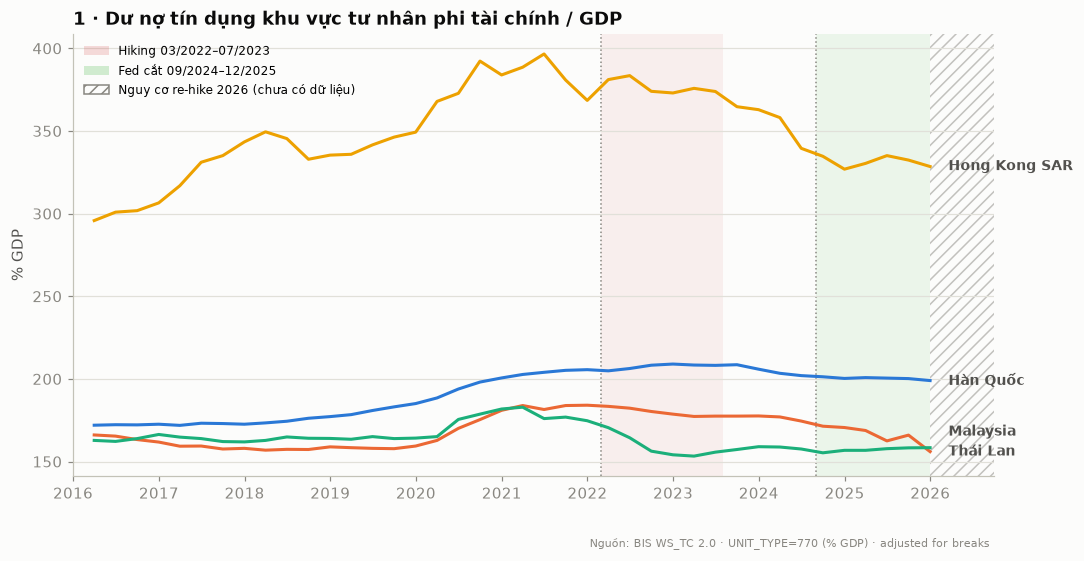

In [16]:
# --- Biểu đồ 1: Credit/GDP (PNFS) theo thời gian -----------------------------
fig, ax = plt.subplots(figsize=(10, 5.2))
shade_phases(ax)
lines = {}
for cty in ORDER:
    s = CREDIT[f"{cty}_P"]
    ax.plot(s.index, s.values, color=COLOR[cty], label=CTY[cty])
    lines[CTY[cty]] = s
label_ends(ax, lines)
ax.set_title("1 · Dư nợ tín dụng khu vực tư nhân phi tài chính / GDP")
ax.set_ylabel("% GDP")
ax.set_xlim(pd.Timestamp("2016-01-01"), pd.Timestamp("2026-10-01"))
ax.legend(handles=PHASE_LEGEND, loc="upper left", fontsize=8, ncol=1)
ax.text(0.995, -0.16, "Nguồn: BIS WS_TC 2.0 · UNIT_TYPE=770 (% GDP) · adjusted for breaks",
        transform=ax.transAxes, ha="right", fontsize=7.5, color=MUTED)
plt.tight_layout(); plt.show()

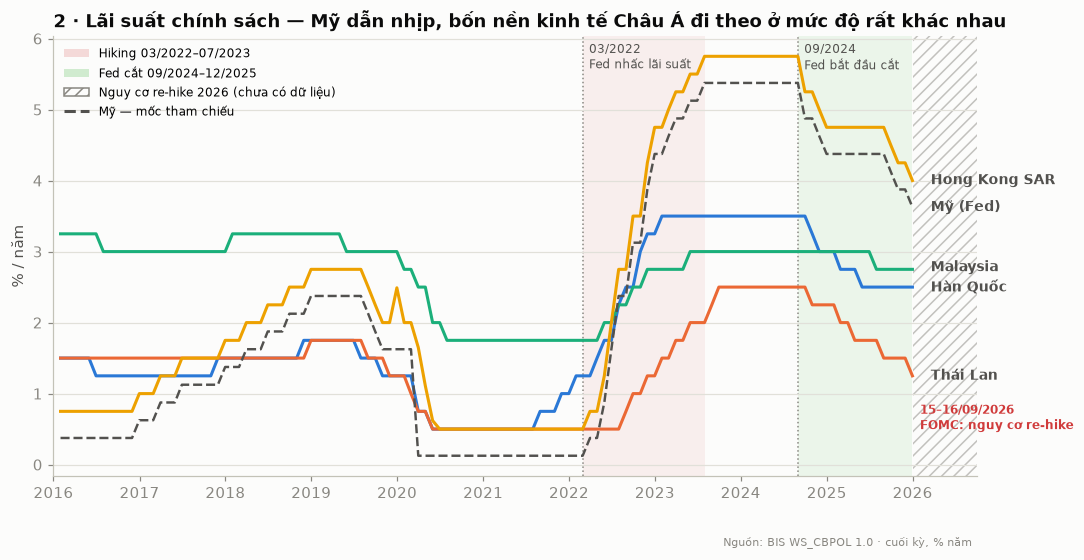

In [17]:
# --- Biểu đồ 2: Lãi suất chính sách + 3 mốc thời gian ------------------------
fig, ax = plt.subplots(figsize=(10, 5.2))
shade_phases(ax)
lines = {}
for cty in ORDER:
    s = POLICY[cty]
    ax.plot(s.index, s.values, color=COLOR[cty])
    lines[CTY[cty]] = s
ax.plot(POLICY["US"].index, POLICY["US"].values, color=INK2, ls="--", lw=1.6)
lines["Mỹ (Fed)"] = POLICY["US"]
label_ends(ax, lines)

for x, txt in [("2022-03-01", "03/2022\nFed nhấc lãi suất"),
               ("2024-09-01", "09/2024\nFed bắt đầu cắt")]:
    ax.annotate(txt, xy=(pd.Timestamp(x), ax.get_ylim()[1]), xytext=(4, -4),
                textcoords="offset points", va="top", fontsize=8, color=INK2)
ax.annotate("15–16/09/2026\nFOMC: nguy cơ re-hike", xy=(pd.Timestamp("2026-02-01"), 0.5),
            fontsize=8, color=CRIT, fontweight="bold")
ax.set_title("2 · Lãi suất chính sách — Mỹ dẫn nhịp, bốn nền kinh tế Châu Á đi theo ở mức độ rất khác nhau")
ax.set_ylabel("% / năm")
ax.set_xlim(pd.Timestamp("2016-01-01"), pd.Timestamp("2026-10-01"))
ax.legend(handles=PHASE_LEGEND + [Line2D([], [], color=INK2, ls="--", label="Mỹ — mốc tham chiếu")],
          loc="upper left", fontsize=8)
ax.text(0.995, -0.16, "Nguồn: BIS WS_CBPOL 1.0 · cuối kỳ, % năm",
        transform=ax.transAxes, ha="right", fontsize=7.5, color=MUTED)
plt.tight_layout(); plt.show()

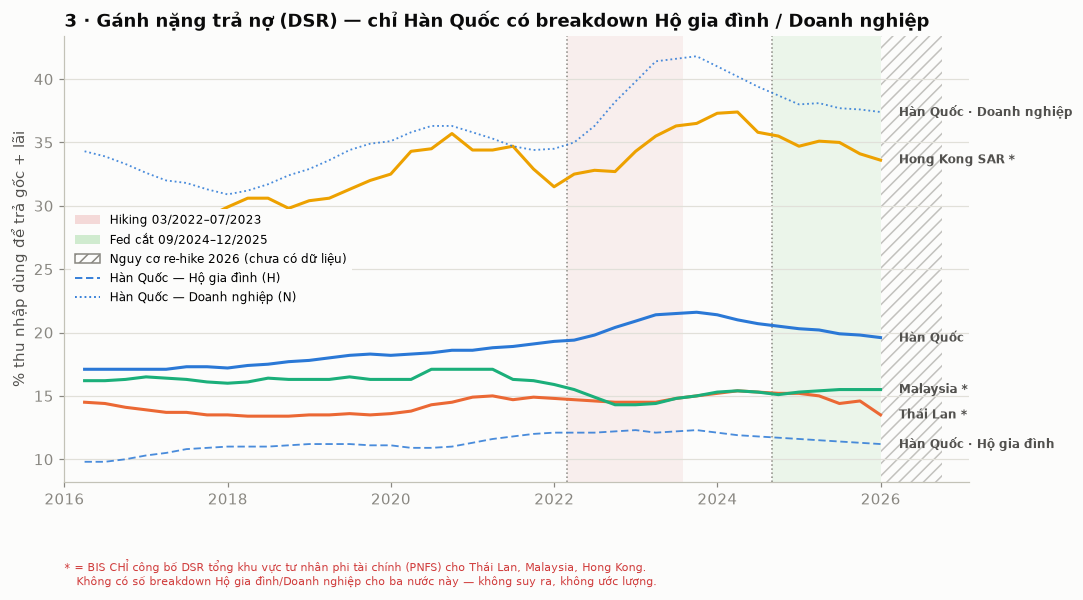

In [18]:
# --- Biểu đồ 3: DSR theo thời gian, ghi rõ nước nào chỉ có PNFS tổng ---------
fig, ax = plt.subplots(figsize=(10, 5.6))
shade_phases(ax)
lines = {}
for cty in ORDER:
    s = DSR[f"{cty}_P"]
    ax.plot(s.index, s.values, color=COLOR[cty])
    tag = CTY[cty] + ("" if cty in HAS_BREAKDOWN else " *")
    lines[tag] = s
# Korea is the only country with the breakdown — draw it as thin dashed context.
for ser, ls in [("KR_H", (0, (4, 2))), ("KR_N", (0, (1, 1.6)))]:
    ax.plot(DSR[ser].index, DSR[ser].values, color=COLOR["KR"], lw=1.2, ls=ls, alpha=0.85)
lines["Hàn Quốc · Hộ gia đình"] = DSR["KR_H"]
lines["Hàn Quốc · Doanh nghiệp"] = DSR["KR_N"]
label_ends(ax, lines, fs=8)

ax.set_title("3 · Gánh nặng trả nợ (DSR) — chỉ Hàn Quốc có breakdown Hộ gia đình / Doanh nghiệp")
ax.set_ylabel("% thu nhập dùng để trả gốc + lãi")
ax.set_xlim(pd.Timestamp("2016-01-01"), pd.Timestamp("2027-02-01"))
ax.legend(handles=PHASE_LEGEND + [
    Line2D([], [], color=COLOR["KR"], lw=1.2, ls=(0, (4, 2)), label="Hàn Quốc — Hộ gia đình (H)"),
    Line2D([], [], color=COLOR["KR"], lw=1.2, ls=(0, (1, 1.6)), label="Hàn Quốc — Doanh nghiệp (N)"),
], loc="center left", fontsize=8,
   frameon=True, framealpha=1, facecolor=SURFACE, edgecolor="none")  # opaque: lines run behind it
ax.text(0.0, -0.17,
        "* = BIS CHỈ công bố DSR tổng khu vực tư nhân phi tài chính (PNFS) cho Thái Lan, Malaysia, Hong Kong.\n"
        "   Không có số breakdown Hộ gia đình/Doanh nghiệp cho ba nước này — không suy ra, không ước lượng.",
        transform=ax.transAxes, ha="left", va="top", fontsize=7.5, color=CRIT)
plt.tight_layout(); plt.show()

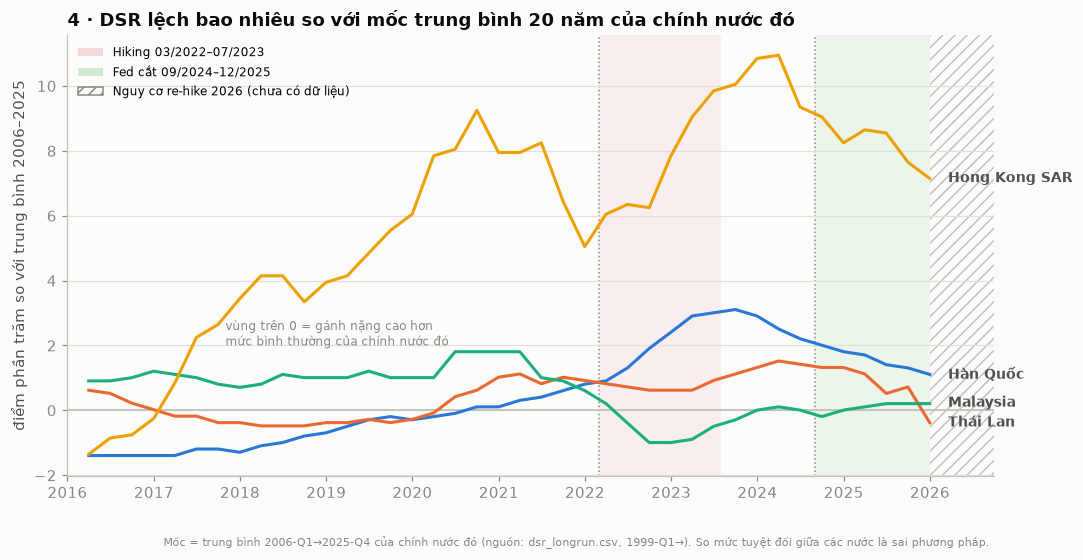

In [19]:
# --- Biểu đồ 4: DSR lệch bao nhiêu so với mốc 20 năm của CHÍNH nước đó -------
# This is the comparison BIS recommends; raw DSR levels are not comparable across
# countries, deviations from each country's own history are.
fig, ax = plt.subplots(figsize=(10, 5.2))
shade_phases(ax)
ax.axhline(0, color="#c3c2b7", lw=1.2)
lines = {}
for cty in ORDER:
    s = DSR_GAP[f"{cty}_P"]
    ax.plot(s.index, s.values, color=COLOR[cty])
    lines[CTY[cty]] = s
label_ends(ax, lines)
ax.set_title("4 · DSR lệch bao nhiêu so với mốc trung bình 20 năm của chính nước đó")
ax.set_ylabel("điểm phần trăm so với trung bình 2006–2025")
ax.set_xlim(pd.Timestamp("2016-01-01"), pd.Timestamp("2026-10-01"))
ax.annotate("vùng trên 0 = gánh nặng cao hơn\nmức bình thường của chính nước đó",
            xy=(pd.Timestamp("2017-10-31"), 2.0), fontsize=8, color=MUTED)
ax.legend(handles=PHASE_LEGEND, loc="upper left", fontsize=8)
ax.text(0.995, -0.16,
        "Mốc = trung bình 2006-Q1→2025-Q4 của chính nước đó (nguồn: dsr_longrun.csv, 1999-Q1→). "
        "So mức tuyệt đối giữa các nước là sai phương pháp.",
        transform=ax.transAxes, ha="right", fontsize=7.5, color=MUTED)
plt.tight_layout(); plt.show()

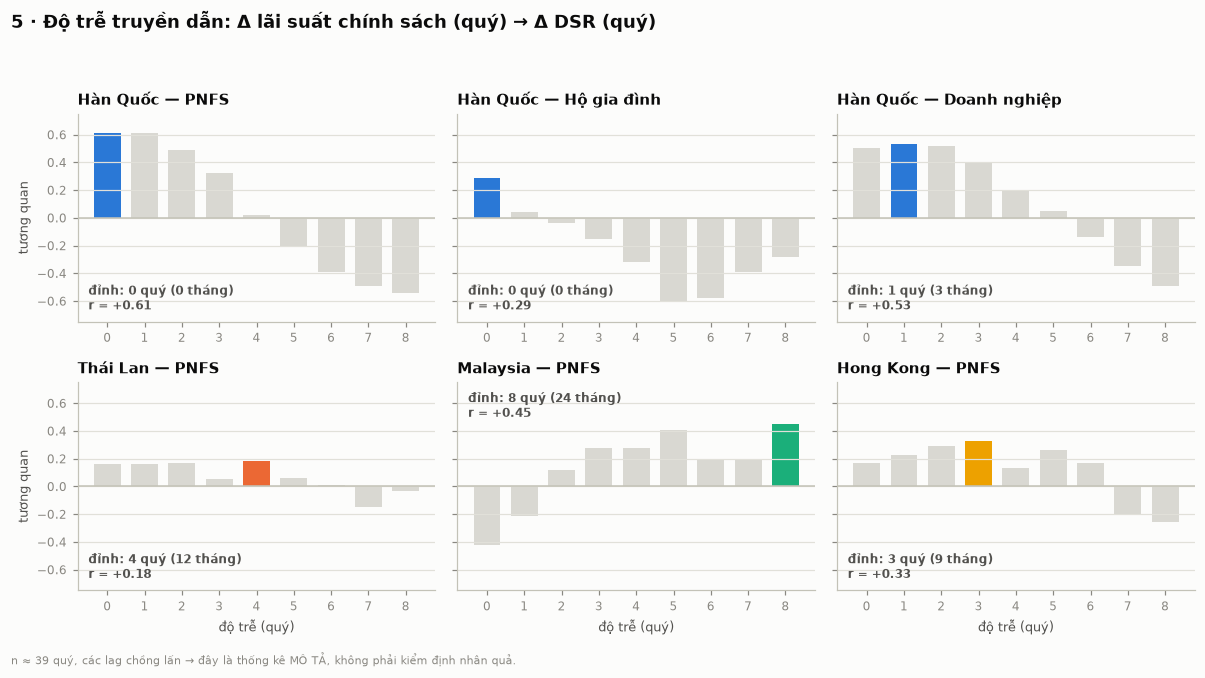

In [20]:
# --- Biểu đồ 5: Độ trễ truyền dẫn — tương quan theo lag, small multiples -----
fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharey=True)
for axx, (cty, ser) in zip(axes.ravel(), PAIRS):
    vals = [CORR.loc[LABEL[ser], f"L{L}"] for L in LAGS]
    best = int(CORR.loc[LABEL[ser], "lag tốt nhất (quý)"])
    cols = [COLOR[cty] if L == best else "#d9d8d2" for L in LAGS]
    axx.bar(list(LAGS), vals, color=cols, width=0.72)
    axx.axhline(0, color="#c3c2b7", lw=1)
    axx.set_title(LABEL[ser], fontsize=9.5)
    axx.set_xticks(list(LAGS)); axx.tick_params(labelsize=8)
    axx.set_ylim(-0.75, 0.75)
    # Park the callout in whichever left corner the bars leave empty, so it never
    # collides with a tall bar or with the panel title.
    corner = (0.03, 0.96, "top") if vals[0] < 0 else (0.03, 0.04, "bottom")
    axx.annotate(f"đỉnh: {best} quý ({best*3} tháng)\nr = {vals[best]:+.2f}",
                 xy=corner[:2], xycoords="axes fraction", ha="left", va=corner[2],
                 fontsize=8, color=INK2, fontweight="bold")
for axx in axes[1]:
    axx.set_xlabel("độ trễ (quý)", fontsize=8.5)
for axx in axes[:, 0]:
    axx.set_ylabel("tương quan", fontsize=8.5)
fig.suptitle("5 · Độ trễ truyền dẫn: Δ lãi suất chính sách (quý) → Δ DSR (quý)",
             x=0.008, ha="left", fontsize=12, fontweight="bold", color=INK)
fig.text(0.008, -0.01,
         "n ≈ 39 quý, các lag chồng lấn → đây là thống kê MÔ TẢ, không phải kiểm định nhân quả.",
         fontsize=7.5, color=MUTED)
plt.tight_layout(rect=(0, 0.01, 1, 0.94)); plt.show()

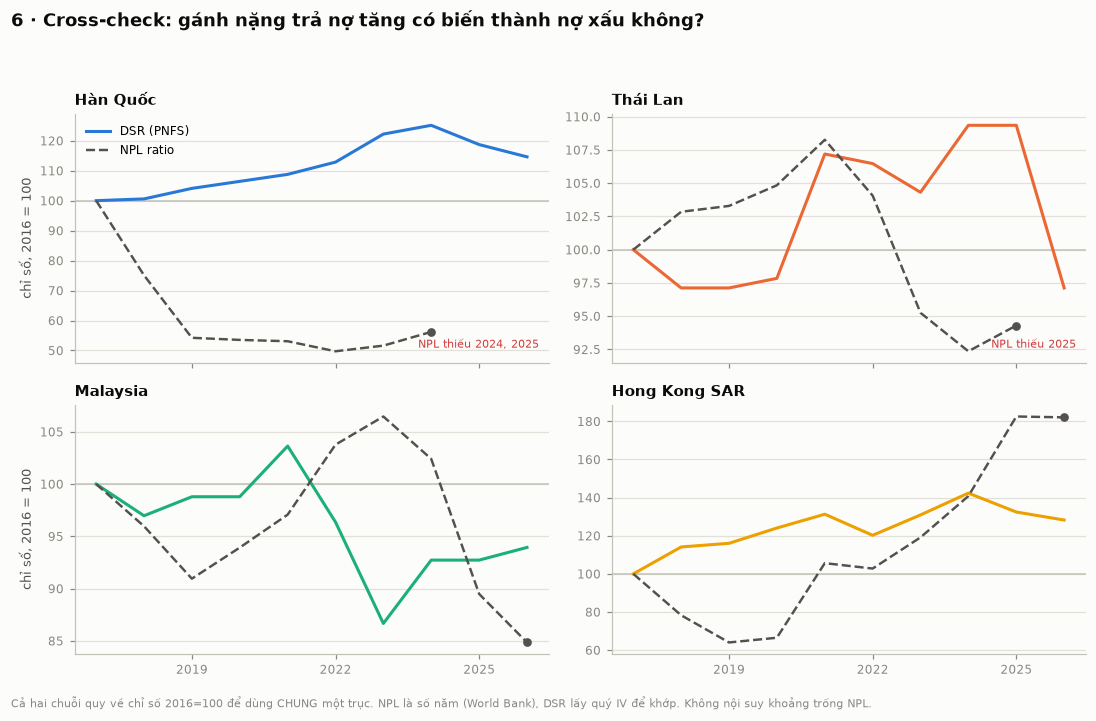

In [21]:
# --- Biểu đồ 6: Cross-check NPL vs DSR --------------------------------------
# Both series indexed to 2016 = 100 so they share ONE axis (never a dual-axis chart).
fig, axes = plt.subplots(2, 2, figsize=(10, 6.4), sharex=True)
for axx, cty in zip(axes.ravel(), ORDER):
    d = DSR_A[f"{cty}_P"]; d = d / d.loc["2016-12-31"] * 100
    n_ = NPL[cty].dropna(); n_ = n_ / NPL[cty].loc["2016-12-31"] * 100
    axx.axhline(100, color="#c3c2b7", lw=1)
    axx.plot(d.index, d.values, color=COLOR[cty], label="DSR (PNFS)")
    axx.plot(n_.index, n_.values, color=INK2, ls="--", lw=1.6, label="NPL ratio")
    axx.scatter(n_.index[-1:], n_.values[-1:], color=INK2, s=22, zorder=3)
    axx.set_title(CTY[cty], fontsize=10)
    axx.tick_params(labelsize=8)
    axx.xaxis.set_major_locator(mdates.YearLocator(3))
    axx.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    gap = [y for y in range(2016, 2026) if pd.Timestamp(f"{y}-12-31") not in n_.index]
    if gap:
        axx.annotate(f"NPL thiếu {', '.join(map(str, gap))}",
                     xy=(0.98, 0.06), xycoords="axes fraction", ha="right",
                     fontsize=7.5, color=CRIT)
axes[0, 0].legend(fontsize=8, loc="upper left")
for axx in axes[:, 0]:
    axx.set_ylabel("chỉ số, 2016 = 100", fontsize=8.5)
fig.suptitle("6 · Cross-check: gánh nặng trả nợ tăng có biến thành nợ xấu không?",
             x=0.008, ha="left", fontsize=12, fontweight="bold", color=INK)
fig.text(0.008, -0.01,
         "Cả hai chuỗi quy về chỉ số 2016=100 để dùng CHUNG một trục. NPL là số năm (World Bank), "
         "DSR lấy quý IV để khớp. Không nội suy khoảng trống NPL.",
         fontsize=7.5, color=MUTED)
plt.tight_layout(rect=(0, 0.01, 1, 0.94)); plt.show()

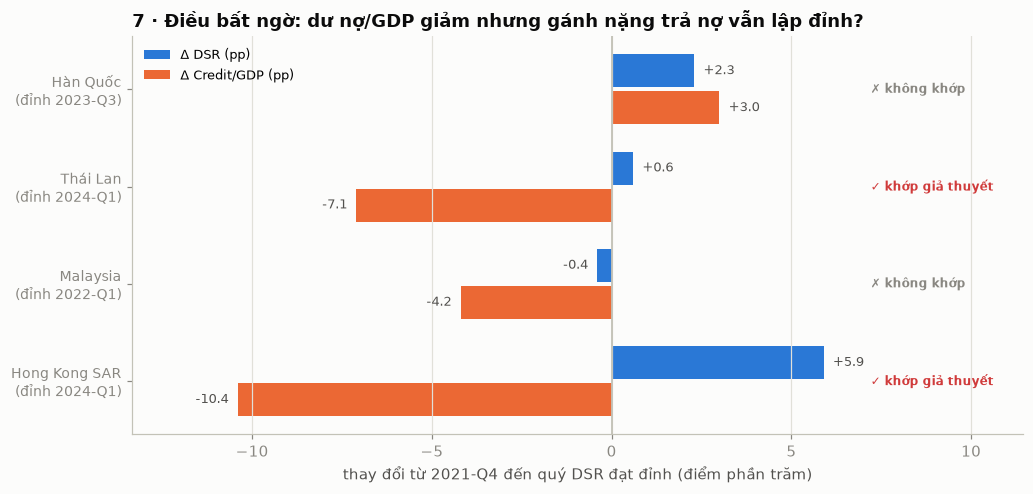

In [22]:
# --- Biểu đồ 7: "Điều bất ngờ" — nợ giảm nhưng gánh nặng tăng? --------------
fig, ax = plt.subplots(figsize=(9.5, 4.6))
y = np.arange(len(SURPRISE))[::-1]
h = 0.34
ax.barh(y + h/2 + 0.02, SURPRISE["ΔDSR (pp)"], height=h, color=SLOT[0], label="Δ DSR (pp)")
ax.barh(y - h/2 - 0.02, SURPRISE["ΔCredit/GDP (pp)"], height=h, color=SLOT[1], label="Δ Credit/GDP (pp)")
ax.axvline(0, color="#c3c2b7", lw=1.2)
ax.set_yticks(y)
ax.set_yticklabels([f"{r['nước']}\n(đỉnh {r['quý DSR đỉnh']})" for _, r in SURPRISE.iterrows()], fontsize=9)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
# Pad both ends: the left pad clears the -10.4 value label, the right pad reserves a
# column for the verdict marks so they never land on a bar or on the legend.
lo = float(SURPRISE[["ΔDSR (pp)", "ΔCredit/GDP (pp)"]].min().min())
hi = float(SURPRISE[["ΔDSR (pp)", "ΔCredit/GDP (pp)"]].max().max())
span = hi - lo
ax.set_xlim(lo - 0.18 * span, hi + 0.34 * span)
VERDICT_X = hi + 0.08 * span
for yy, (_, r) in zip(y, SURPRISE.iterrows()):
    ax.annotate(f"{r['ΔDSR (pp)']:+.1f}", xy=(r["ΔDSR (pp)"], yy + h/2 + 0.02),
                xytext=(6 if r["ΔDSR (pp)"] >= 0 else -6, 0), textcoords="offset points",
                va="center", ha="left" if r["ΔDSR (pp)"] >= 0 else "right", fontsize=8.5, color=INK2)
    ax.annotate(f"{r['ΔCredit/GDP (pp)']:+.1f}", xy=(r["ΔCredit/GDP (pp)"], yy - h/2 - 0.02),
                xytext=(6 if r["ΔCredit/GDP (pp)"] >= 0 else -6, 0), textcoords="offset points",
                va="center", ha="left" if r["ΔCredit/GDP (pp)"] >= 0 else "right", fontsize=8.5, color=INK2)
    ok = r["khớp 'bất ngờ'?"] == "CÓ"
    ax.annotate("✓ khớp giả thuyết" if ok else "✗ không khớp",
                xy=(VERDICT_X, yy), ha="left", va="center",
                fontsize=8, fontweight="bold", color=CRIT if ok else MUTED)
ax.set_title("7 · Điều bất ngờ: dư nợ/GDP giảm nhưng gánh nặng trả nợ vẫn lập đỉnh?")
ax.set_xlabel("thay đổi từ 2021-Q4 đến quý DSR đạt đỉnh (điểm phần trăm)")
ax.legend(fontsize=8.5, loc="upper left")
plt.tight_layout(); plt.show()

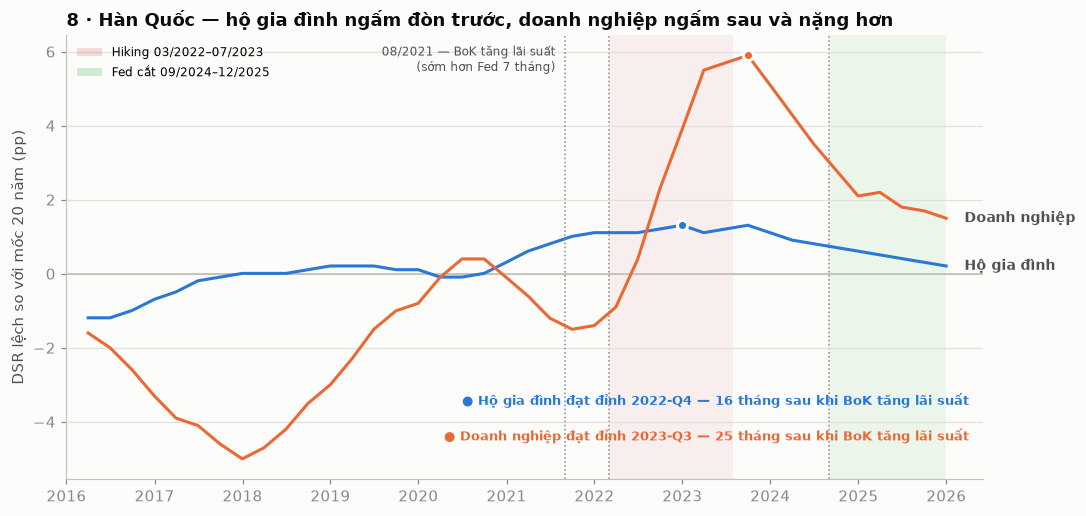

In [23]:
# --- Biểu đồ 8: Hàn Quốc — hộ gia đình và doanh nghiệp phản ứng khác nhịp ----
# Only Korea has the breakdown, so this chart exists for one country by necessity.
fig, ax = plt.subplots(figsize=(10, 4.8))
shade_phases(ax, risk=False)
h = DSR["KR_H"] - BENCH["KR_H"]
n_ = DSR["KR_N"] - BENCH["KR_N"]
ax.axhline(0, color="#c3c2b7", lw=1.2)
ax.plot(h.index, h.values, color=SLOT[0])
ax.plot(n_.index, n_.values, color=SLOT[1])
label_ends(ax, {"Hộ gia đình": h, "Doanh nghiệp": n_})
for k, (s, c, lb) in enumerate([(h, SLOT[0], "Hộ gia đình"), (n_, SLOT[1], "Doanh nghiệp")]):
    pk = s.loc["2021-08-31":].idxmax()
    ax.scatter([pk], [s.loc[pk]], color=c, s=44, zorder=4, edgecolor=SURFACE, linewidth=2)
    lag = (pk.year - 2021) * 12 + (pk.month - 8)
    # Both callouts go in the empty bottom-right block rather than beside their dots:
    # the two peaks sit too close to the title and to each other's line to label inline.
    ax.annotate(f"● {lb} đạt đỉnh {pk.year}-Q{pk.quarter} — {lag} tháng sau khi BoK tăng lãi suất",
                xy=(0.985, 0.16 - 0.08 * k), xycoords="axes fraction",
                ha="right", va="bottom", fontsize=8.5, color=c, fontweight="bold")
ax.axvline(CYCLE["KR"]["start"], color=MUTED, lw=1, ls=":")
ax.annotate("08/2021 — BoK tăng lãi suất\n(sớm hơn Fed 7 tháng)",
            xy=(CYCLE["KR"]["start"], ax.get_ylim()[1]), xytext=(-6, -6),
            textcoords="offset points", va="top", ha="right", fontsize=8, color=INK2)
ax.set_title("8 · Hàn Quốc — hộ gia đình ngấm đòn trước, doanh nghiệp ngấm sau và nặng hơn")
ax.set_ylabel("DSR lệch so với mốc 20 năm (pp)")
ax.set_xlim(pd.Timestamp("2016-01-01"), pd.Timestamp("2026-06-01"))
ax.legend(handles=PHASE_LEGEND[:2], loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

---
# Câu chuyện dữ liệu

*(Cấu trúc 9 bước theo mục 24 của đề. Mọi con số dưới đây đều lấy từ các bảng vừa chạy ở trên.)*

In [24]:
# Re-print the three numbers the story leans on hardest, so the narrative below is
# always checkable against the output of this run.
print("BẢNG ĐIỂM HỒI PHỤC")
print(RECOVERY.to_string(index=False))
print("\nĐỘ TRỄ QUAN SÁT ĐƯỢC")
print(LAG[["chuỗi", "NHTW tăng lần đầu", "độ trễ (tháng)", "mức tăng (pp)", "khớp GT 12–18t?"]].to_string(index=False))
print("\nCROSS-CHECK NPL")
print(CROSS[["nước", "ΔDSR 2021→đỉnh (pp)", "NPL 2021", "NPL gần nhất", "năm", "ΔNPL (pp)", "NPL có tăng?"]].to_string(index=False))

BẢNG ĐIỂM HỒI PHỤC
                  chuỗi  đỉnh sau 2022  2025-Q4  Δ từ đỉnh (pp)  mốc 20 năm  còn vượt mốc (pp)  đã gỡ được (%)
       Hong Kong — PNFS           37.4     33.6            -3.8        26.5                7.1            35.0
Hàn Quốc — Doanh nghiệp           41.8     37.4            -4.4        35.9                1.5            75.0
        Hàn Quốc — PNFS           21.6     19.6            -2.0        18.5                1.1            64.0
 Hàn Quốc — Hộ gia đình           12.3     11.2            -1.1        11.0                0.2            84.0
        Malaysia — PNFS           15.5     15.5             0.0        15.3                0.2             0.0
        Thái Lan — PNFS           15.4     13.5            -1.9        13.9               -0.4           125.0

ĐỘ TRỄ QUAN SÁT ĐƯỢC
                  chuỗi NHTW tăng lần đầu  độ trễ (tháng)  mức tăng (pp) khớp GT 12–18t?
        Hàn Quốc — PNFS           08/2021              25            2.7           KHÔNG
 Hàn

## 1. Mở đầu — tín hiệu đáng chú ý

Tháng 9/2026, Fed đang cân nhắc tăng lãi suất trở lại. Nhưng bốn nền kinh tế Châu Á có tỷ lệ
nợ tư nhân cao nhất khu vực **chưa đứng dậy khỏi vòng thắt chặt trước ở cùng một mức độ** —
và khoảng cách giữa họ lớn đến mức không thể gộp chung thành một câu chuyện "Châu Á".

Cuối 2025, gánh nặng trả nợ của khu vực tư nhân Hong Kong vẫn ở **33.6%** thu nhập, cao hơn
**+7.1 điểm phần trăm** so với mức trung bình 20 năm của chính Hong Kong — tức mới chỉ gỡ được
**35%** phần vượt mức tạo ra trong chu kỳ hiking. Cùng thời điểm, Thái Lan đã xuống **13.5%**,
**thấp hơn** mốc 20 năm của mình 0.4pp: gỡ xong 100% và còn dư.

Bốn nước, cùng một cú sốc lãi suất từ Washington, bốn kết cục khác hẳn nhau.

## 2. Câu hỏi — rủi ro nào?

Nếu FOMC ngày 15–16/9/2026 tăng lãi suất trở lại, ai bước vào vòng hai từ vị thế đã kiệt sức,
và ai còn dư địa? Câu hỏi này chỉ trả lời được nếu tách bạch **hai thứ hay bị nhầm lẫn**:

- **Dư nợ / GDP** — quy mô đòn bẩy, món nợ *to* bao nhiêu (BIS `WS_TC`).
- **DSR** — phần trăm thu nhập thực sự phải chi ra để trả gốc + lãi mỗi kỳ (BIS `WS_DSR`).

Một nền kinh tế có thể **giảm nợ mà vẫn ngộp thở**, nếu lãi suất trên phần nợ còn lại tăng
nhanh hơn tốc độ trả bớt. Đó chính là điều xảy ra, và biểu đồ 7 cho thấy nó xảy ra ở đâu.

## 3. Ai vay / ai cho vay?

`TC_LENDERS = A` (All sectors) — dư nợ tính cả ngân hàng trong nước, nước ngoài, trái phiếu và
các nguồn phi ngân hàng, nên "tín dụng" ở đây rộng hơn "tín dụng ngân hàng".

Về phía người vay, **giới hạn dữ liệu quyết định luôn độ sâu của câu chuyện**:

- **DSR** có breakdown Hộ gia đình (`H`) / Doanh nghiệp (`N`) **chỉ ở Hàn Quốc**. Thái Lan,
  Malaysia, Hong Kong chỉ có DSR tổng PNFS (`P`). Đây là giới hạn công bố của BIS — kiểm tra
  bằng bảng đếm quan sát ở mục ②, không phải NaN cần xử lý.
- **Dư nợ/GDP thì có breakdown H/N đủ cả bốn nước.** Nên câu hỏi "ai vay" trả lời được ở cả
  bốn, nhưng câu hỏi "ai đang ngộp thở" thì **chỉ Hàn Quốc trả lời được**.

Cấu trúc người vay khác nhau rõ rệt (2025-Q4, % GDP): Hong Kong nghiêng hẳn về **doanh nghiệp**
(240.7% GDP, so với hộ gia đình 87.8%) — di sản của trung tâm tài chính và bất động sản thương mại.
Hàn Quốc và Thái Lan cân bằng hơn giữa hai khu vực (Hàn Quốc 88.6 / 110.4; Thái Lan 87.5 / 68.5).

## 4. Dữ liệu cho thấy gì?

**Cường độ cú sốc lãi suất khác nhau tới bốn lần.** Từ đáy 2021 đến đỉnh:
Hong Kong **+5.25pp** (0.50% → 5.75%), Hàn Quốc **+3.00pp**, Thái Lan **+2.00pp**,
Malaysia chỉ **+1.25pp**. Hong Kong tăng đúng bằng Fed (+5.25pp) và đúng tháng với Fed
(03/2022) — hệ quả cơ học của chế độ neo tỷ giá: HKMA không có lựa chọn nào khác.
Malaysia gần như miễn nhiễm.

**Và kết quả đúng theo thứ tự cường độ.** Mức DSR vượt mốc 20 năm tại đỉnh:
Hong Kong +10.9pp, Hàn Quốc +3.1pp, Thái Lan +1.5pp, Malaysia +0.2pp.
Nước nào bị buộc phải theo Fed sát nhất thì trả giá đắt nhất.

## 5. Tín hiệu cảnh báo

Giả thuyết đề cương: **DSR tăng đột biến 12–18 tháng sau khi NHTW bắt đầu tăng lãi suất.**

**Dữ liệu chỉ ủng hộ một phần — và độ trễ thật DÀI HƠN giả thuyết.** Tính từ lần tăng lãi
suất đầu tiên của chính NHTW đó đến quý DSR đạt đỉnh:

| Chuỗi | NHTW tăng lần đầu | Độ trễ thật | Khớp 12–18 tháng? |
|---|---|---|---|
| Hàn Quốc — **Hộ gia đình** | 08/2021 | **16 tháng** | **CÓ** |
| Thái Lan — PNFS | 08/2022 | 19 tháng | Sát ngoài |
| Hong Kong — PNFS | 03/2022 | 24 tháng | KHÔNG |
| Hàn Quốc — PNFS / Doanh nghiệp | 08/2021 | 25 tháng | KHÔNG |
| Malaysia — PNFS | 05/2022 | (không có đỉnh do lãi suất) | KHÔNG |

Chỉ **1/6 chuỗi** rơi đúng khoảng 12–18 tháng. Trung vị độ trễ quan sát được là **24.5 tháng**
(24 tháng nếu bỏ Malaysia — nước mà DSR không hề có đỉnh nào do lãi suất gây ra).

**Đây là một phát hiện, không phải một thất bại** — và nó làm rủi ro *tệ hơn*, không nhẹ đi:
nếu độ trễ thật là ~2 năm chứ không phải ~1.5 năm, thì một đợt re-hike tháng 9/2026 sẽ đổ gánh
nặng xuống tận **2028**, chồng lên phần vượt mức mà Hong Kong còn chưa gỡ xong từ vòng trước.

Tương quan theo lag (biểu đồ 5) xác nhận sự phân hoá: Hàn Quốc truyền dẫn **nhanh và mạnh**
(r = +0.61 ngay ở lag 0–1 quý — nợ vay lãi suất thả nổi tái định giá gần như tức thì),
còn Thái Lan (r chỉ +0.18) và Malaysia (r âm ở lag ngắn) gần như không có tín hiệu truyền dẫn
ngắn hạn nào.

## 6. Kiểm tra bằng chỉ tiêu khác — NPL ratio (World Bank)

**Cross-check này bác bỏ mối liên hệ mà ta mong đợi tìm thấy, ở 3 trên 4 nước.**

| Nước | Δ DSR 2021→đỉnh | NPL 2021 → gần nhất | Nợ xấu có tăng? |
|---|---|---|---|
| **Hong Kong** | **+5.9pp** | 0.88 → **1.56** (2025) | **CÓ, +77%** |
| Hàn Quốc | +2.3pp | 0.23 → 0.26 (2023) | Gần như đứng yên |
| Thái Lan | +0.6pp | 3.11 → 2.82 (2024) | **GIẢM** |
| Malaysia | −0.4pp | 1.68 → 1.37 (2025) | **GIẢM** |

Chỉ Hong Kong cho thấy chuỗi truyền dẫn kinh điển *lãi suất → gánh nặng trả nợ → vỡ nợ*
(tương quan mức +0.54). Ở Hàn Quốc và Thái Lan, tương quan mức thậm chí **âm** (−0.58 và −0.46):
DSR đi lên trong khi nợ xấu đi xuống.

Ba cách giải thích, không loại trừ nhau: (a) hộ gia đình **thắt lưng buộc bụng để trả nợ đúng
hạn** — gánh nặng có thật nhưng chưa thành vỡ nợ, và cái giá nằm ở tiêu dùng bị hy sinh chứ
không nằm ở sổ sách ngân hàng; (b) các biện pháp **giãn/tái cơ cấu nợ** hậu COVID giữ khoản vay
ở trạng thái "bình thường" trên báo cáo; (c) NPL là **chỉ báo trễ**, và ta còn thiếu đúng hai
năm cuối ở Hàn Quốc.

*Cảnh báo dữ liệu: World Bank chưa có NPL Hàn Quốc 2024–2025 và Thái Lan 2025. Không nội suy —
cột "năm" trong bảng cho biết mốc so sánh thật của từng nước, và biểu đồ 6 ghi rõ khoảng trống.*

## 7. Điều bất ngờ

Giả thuyết đề cương: **dư nợ/GDP giảm nhẹ, nhưng DSR lại lập đỉnh.**

**Đúng ở 2/4 nước — và chỗ nó SAI mới là chỗ đáng nói.**

- ✅ **Hong Kong** — bản mẫu hoàn hảo của giả thuyết: từ 2021-Q4 đến đỉnh 2024-Q1,
  dư nợ/GDP **giảm 10.4pp** trong khi DSR **tăng 5.9pp**. Nợ ít đi, mà trả nặng hơn hẳn.
- ✅ **Thái Lan** — cùng chiều nhưng nhẹ: dư nợ −7.1pp, DSR +0.6pp.
- ❌ **Hàn Quốc** — ngược hẳn: **cả hai cùng tăng** (dư nợ +3.0pp, DSR +2.3pp). Gánh nặng của
  Hàn Quốc không phải do lãi suất bóp một món nợ đang co lại, mà do **vay thêm giữa lúc lãi suất
  đang lên**. Đó là một loại rủi ro khác hẳn, và tệ hơn về mặt chất lượng.
- ❌ **Malaysia** — cả hai cùng giảm. Không có nghịch lý nào: giảm đòn bẩy thật sự.

Điều bất ngờ *thật sự*, nằm ngoài đề cương: **chính sách tiền tệ độc lập là tấm khiên đo được
bằng số.** Malaysia — nước duy nhất không phải chạy theo Fed (chỉ tăng 1.25pp) — kết thúc chu kỳ
với DSR gần như không đổi và nợ xấu **giảm**. Hong Kong — nước không có lựa chọn vì neo tỷ giá —
lĩnh trọn mọi thiệt hại. Cùng một cú sốc từ Fed, hai kết cục ở hai cực, và biến số phân biệt
chúng là **quyền tự quyết về lãi suất**.

## 8. Tại sao điều này quan trọng?

Nếu Fed tăng lãi suất trở lại tháng 9/2026, bốn nước bước vào vòng hai từ bốn vạch xuất phát
khác nhau — và **thứ tự rủi ro không giống thứ tự mà mức DSR tuyệt đối gợi ý**:

| | Còn vượt mốc 20 năm | Đã gỡ được | Lãi suất hiện tại |
|---|---|---|---|
| 🔴 **Hong Kong** | **+7.1pp** | chỉ 35% | 4.00% (neo theo Fed) |
| 🟠 Hàn Quốc — Doanh nghiệp | +1.5pp | 75% | 2.50% |
| 🟡 Hàn Quốc — Hộ gia đình | +0.2pp | 84% | 2.50% |
| 🟢 Malaysia | +0.2pp | — (chưa từng vượt đáng kể) | 2.75% |
| 🟢 **Thái Lan** | **−0.4pp** | 100%+ | 1.25% |

**Hong Kong là nơi rủi ro tập trung**, vì ba lý do cộng dồn: gánh nặng còn cao nhất so với lịch
sử của chính mình, tốc độ hồi phục chậm nhất, và — quan trọng nhất — **không có quyền từ chối
đợt tăng tiếp theo**. Cơ chế neo tỷ giá bảo đảm rằng nếu Fed tăng, HKMA tăng theo, bất kể khu
vực tư nhân Hong Kong đã kịp hồi sức hay chưa. Thêm vào đó, Hong Kong là nước duy nhất nợ xấu
**đã bắt đầu tăng thật** (+77% từ 2021) — tức chuỗi truyền dẫn tới vỡ nợ ở đây không còn là giả
thuyết nữa.

Thái Lan ở cực ngược lại: gánh nặng đã dưới mức bình thường, và với lãi suất chính sách
1.25% — thấp nhất nhóm — BoT còn dư địa cắt tiếp nếu cần.

## 9. Giới hạn của phân tích

1. **DSR breakdown chỉ có ở Hàn Quốc.** Với Thái Lan/Malaysia/Hong Kong ta chỉ có PNFS tổng,
   nên không tách được hộ gia đình và doanh nghiệp — trong khi biểu đồ 8 cho thấy ở Hàn Quốc hai
   nhóm này đạt đỉnh **cách nhau 9 tháng** (hộ gia đình 2022-Q4, doanh nghiệp 2023-Q3). Rất có
   thể Hong Kong cũng có độ lệch tương tự, nhưng **dữ liệu không cho phép khẳng định, nên không
   khẳng định**. Dư nợ/GDP tách H/N (có đủ 4 nước) chỉ là proxy cho câu hỏi "ai vay" — nó đo
   **quy mô nợ**, không đo **gánh nặng trả nợ**, và không thay thế được DSR breakdown.
2. **NPL là số năm và còn thiếu.** Hàn Quốc 2024–2025, Thái Lan 2025 chưa có. Ghép DSR quý IV
   với NPL năm cho mỗi nước tối đa 10 điểm — mọi hệ số tương quan ở mục 5.3 là **mô tả**, không
   đủ bậc tự do để kiểm định. Đã chọn hạ tần suất thay vì nội suy NPL lên quý, chính vì nội suy
   sẽ tạo ra quan sát bịa rồi dùng chúng để tính tương quan.
3. **DSR của BIS giả định kỳ hạn còn lại và cơ cấu trả nợ cố định** theo phương pháp luận chuẩn
   hoá của BIS. Nó so sánh được qua thời gian trong cùng một nước, nhưng mức tuyệt đối giữa các
   nước thì không — vì vậy toàn bộ so sánh xuyên quốc gia ở đây dùng **độ lệch so với mốc 20 năm
   của chính nước đó** (biểu đồ 4), không dùng mức thô.
4. **Tương quan không phải nhân quả.** Giai đoạn 2020–2022 có COVID, các gói hỗ trợ tài khoá và
   chương trình giãn nợ chồng lấn lên tín hiệu lãi suất. Đỉnh DSR 2020-Q2 của Malaysia là hiệu
   ứng mẫu số (GDP sụp), không phải hiệu ứng lãi suất — đã loại khỏi phép đo độ trễ bằng cách
   chỉ tính đỉnh **sau** ngày NHTW tăng lãi suất.
5. **Vùng 2026 trên mọi biểu đồ là vùng gạch chéo rỗng.** Dữ liệu dừng ở 31/12/2025; nguy cơ
   re-hike là bối cảnh để định vị câu chuyện, **không có một điểm dữ liệu nào được vẽ ở đó**.